**PHASE 1**

In [ ]:
import pandas as pd
data = pd.read_csv("556fd785-1006-11f1-91f6-bc97e148b76b-O-result.csv")
data.head()

,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag
0,44.983097,0.096406,2.736716,2.703127,-14.520762,18.629124,20.095362,17.397757
1,45.146386,0.160353,2.358857,14.037364,-14.364990,17.871004,19.115332,16.781527
2,45.067319,0.144901,0.968221,5.603055,-1.349030,20.345776,21.087496,19.217527
3,44.973696,0.155204,8.053747,220.147548,37.502771,16.282227,17.650950,15.139704
4,44.939819,0.158102,0.223937,25.804099,-36.513884,19.555052,NaN,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ra                200000 non-null  float64
 1   dec               200000 non-null  float64
 2   parallax          200000 non-null  float64
 3   pmra              200000 non-null  float64
 4   pmdec             200000 non-null  float64
 5   phot_g_mean_mag   199911 non-null  float64
 6   phot_bp_mean_mag  198667 non-null  float64
 7   phot_rp_mean_mag  198768 non-null  float64
dtypes: float64(8)
memory usage: 12.2 MB


In [ ]:
print("Shape:", data.shape)
print("\nColumns:\n", data.columns)
print("\nMissing values:\n", data.isnull().sum())

Shape: (200000, 8)

Columns:
 Index(['ra', 'dec', 'parallax', 'pmra', 'pmdec', 'phot_g_mean_mag',
       'phot_bp_mean_mag', 'phot_rp_mean_mag'],
      dtype='object')

Missing values:
 ra                     0
dec                    0
parallax               0
pmra                   0
pmdec                  0
phot_g_mean_mag       89
phot_bp_mean_mag    1333
phot_rp_mean_mag    1232
dtype: int64


In [ ]:
data = data.dropna(subset=[
    'ra',
    'dec',
    'parallax',
    'pmra',
    'pmdec',
    'phot_g_mean_mag',
    'phot_bp_mean_mag',
    'phot_rp_mean_mag'
])

print("Shape after removing missing values:", data.shape)

Shape after removing missing values: (198665, 8)


In [ ]:
data = data[data['parallax'] > 0]
print("Shape after removing invalid parallax:", data.shape)

Shape after removing invalid parallax: (198665, 8)


In [ ]:
data.reset_index(drop=True, inplace=True)

In [ ]:
data['color_index'] = data['phot_bp_mean_mag'] - data['phot_rp_mean_mag']

In [ ]:
import numpy as np
data['total_pm'] = np.sqrt(data['pmra']**2 + data['pmdec']**2)

In [ ]:
data['distance_pc'] = 1000 / data['parallax']

In [ ]:
print(data.head())
print("Final shape:", data.shape)

print("\nSummary Statistics:\n")
print(data.describe())

          ra       dec  parallax        pmra      pmdec  phot_g_mean_mag  \
0  44.983097  0.096406  2.736716    2.703127 -14.520762        18.629124   
1  45.146386  0.160353  2.358857   14.037364 -14.364990        17.871004   
2  45.067319  0.144901  0.968221    5.603055  -1.349030        20.345776   
3  44.973696  0.155204  8.053747  220.147548  37.502771        16.282227   
4  44.925622  0.168833  0.517393    3.494989  -5.779863        16.271992   

   phot_bp_mean_mag  phot_rp_mean_mag  color_index    total_pm  distance_pc  
0         20.095362         17.397757     2.697605   14.770220   365.401463  
1         19.115332         16.781527     2.333805   20.084833   423.934081  
2         21.087496         19.217527     1.869969    5.763168  1032.822140  
3         17.650950         15.139704     2.511246  223.319056   124.165807  
4         16.678385         15.691676     0.986709    6.754388  1932.768478  
Final shape: (198665, 11)

Summary Statistics:

                  ra       

In [ ]:
from google.colab import files
data.to_csv("gaia_phase1_cleaned.csv", index=False)
files.download("gaia_phase1_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

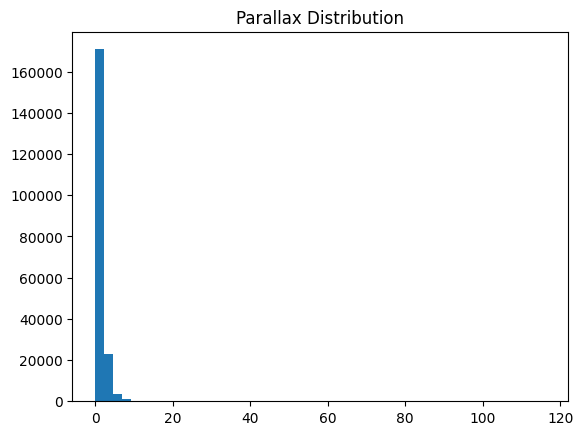

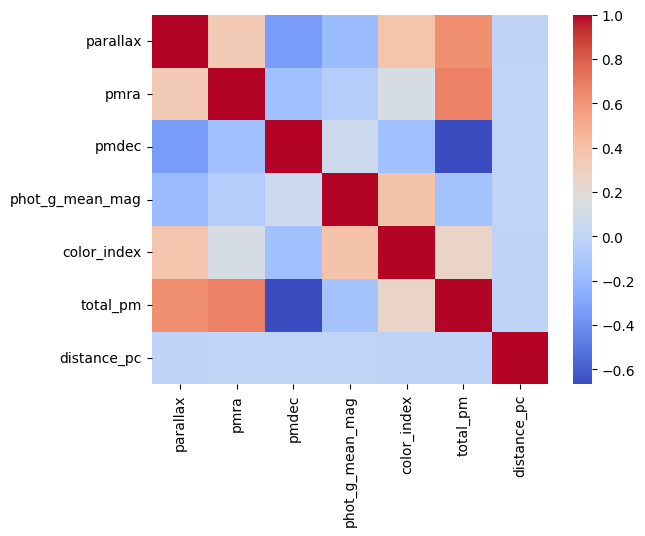

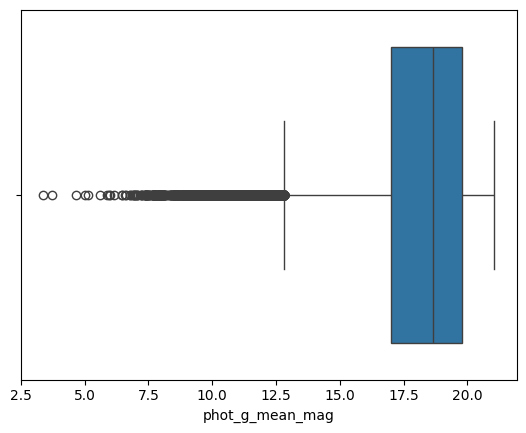

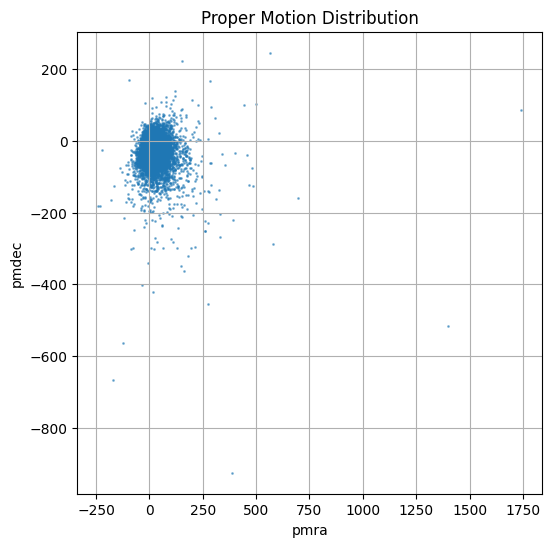

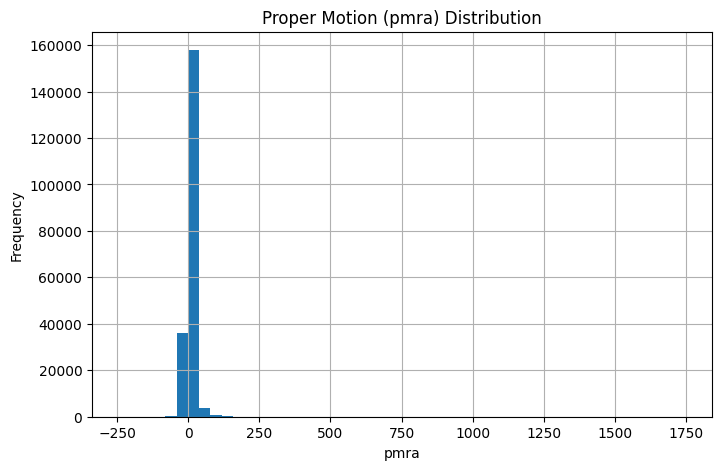

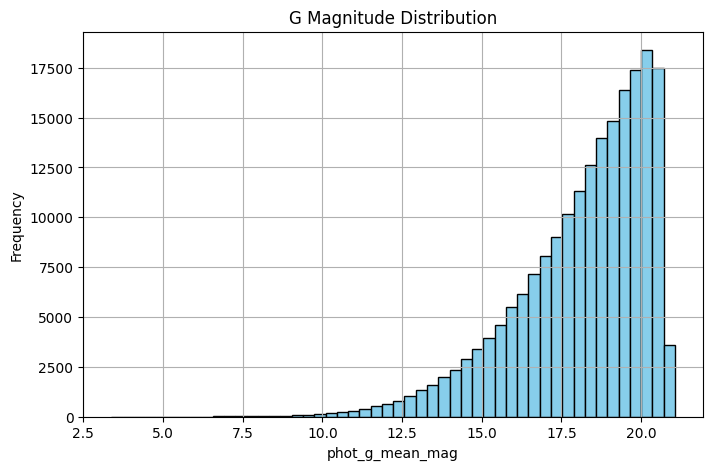

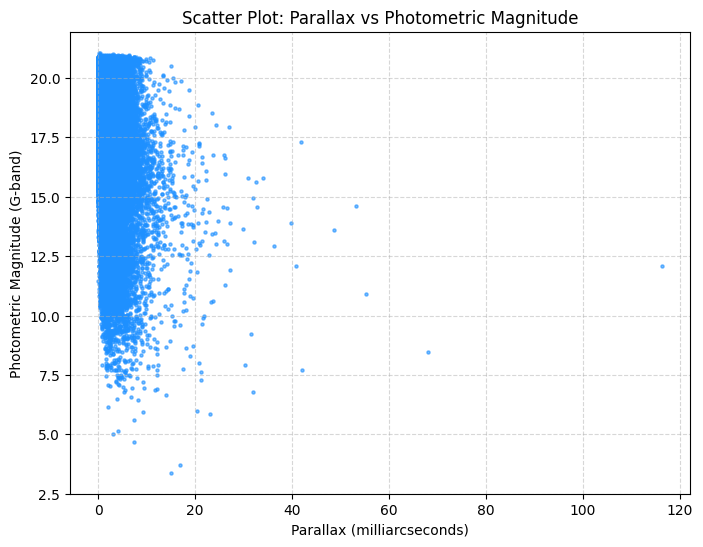

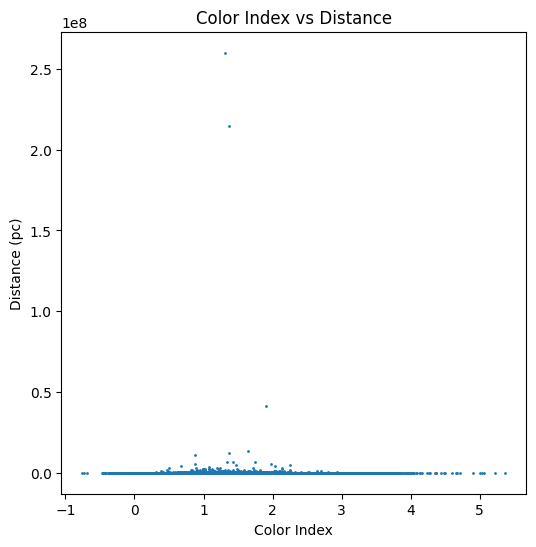

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
plt.hist(data['parallax'], bins=50)
plt.title("Parallax Distribution")
plt.show()

# Correlation heatmap
sns.heatmap(data[['parallax','pmra','pmdec','phot_g_mean_mag',
                  'color_index','total_pm','distance_pc']].corr(),
            cmap='coolwarm', annot=False)
plt.show()

# Boxplot
sns.boxplot(x=data['phot_g_mean_mag'])
plt.show()
# Scatter: pmra vs pmdec
plt.figure(figsize=(6,6))
plt.scatter(data['pmra'], data['pmdec'], s=1,alpha=0.5)
plt.xlabel("pmra")
plt.ylabel("pmdec")
plt.title("Proper Motion Distribution")
plt.grid(True)
plt.show()

#Histogram :pmra
plt.figure(figsize=(8,5))
plt.hist(data['pmra'], bins=50)
plt.title("Proper Motion (pmra) Distribution")
plt.xlabel("pmra")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Histogram: phot_g_mean_mag
plt.figure(figsize=(8,5))
plt.hist(data['phot_g_mean_mag'], bins=50,color='skyblue', edgecolor='black')
plt.title("G Magnitude Distribution")
plt.xlabel("phot_g_mean_mag")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(data['parallax'], data['phot_g_mean_mag'], s=5, color='dodgerblue',
            alpha=0.6)
plt.title("Scatter Plot: Parallax vs Photometric Magnitude")
plt.xlabel("Parallax (milliarcseconds)")
plt.ylabel("Photometric Magnitude (G-band)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Optional: Scatter color_index vs distance_pc
plt.figure(figsize=(6,6))
plt.scatter(data['color_index'], data['distance_pc'], s=1)
plt.xlabel("Color Index")
plt.ylabel("Distance (pc)")
plt.title("Color Index vs Distance")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
# Add engineered features to PCA
features_full = data[['parallax','pmra','pmdec','phot_g_mean_mag',
                    'color_index','total_pm','distance_pc']]

# Scale all features
scaled_full = StandardScaler().fit_transform(features_full)

# Convert to DataFrame to show scaled values
scaled_data = pd.DataFrame(scaled_full, columns=features_full.columns)
print(scaled_data.head())  # Screenshot this for report

   parallax       pmra     pmdec  phot_g_mean_mag  color_index   total_pm  \
0  0.981017  -0.224124 -0.575794         0.224763     1.543415   0.085320   
1  0.717863   0.532626 -0.563979        -0.138985     0.961020   0.388823   
2 -0.250627  -0.030506  0.423258         1.048418     0.218481  -0.429049   
3  4.683990  14.293935  3.370095        -0.901285     1.245079  11.994977   
4 -0.564600  -0.171254  0.087187        -0.906196    -1.195499  -0.372443   

   distance_pc  
0    -0.007905  
1    -0.007828  
2    -0.007033  
3    -0.008220  
4    -0.005858  


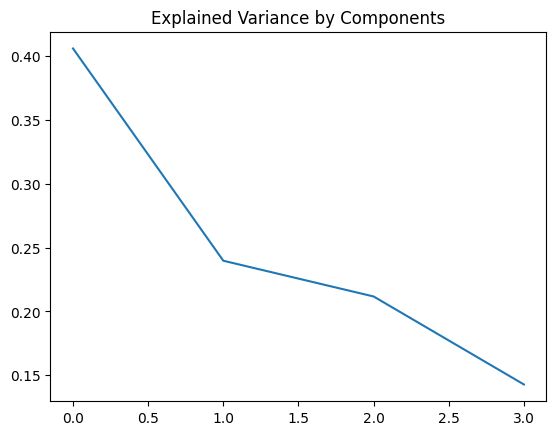

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
features = data[['parallax','pmra','pmdec','phot_g_mean_mag']]
scaled = StandardScaler().fit_transform(features)
pca = PCA()
pca_data = pca.fit_transform(scaled)
plt.plot(pca.explained_variance_ratio_)
plt.title("Explained Variance by Components")
plt.show()

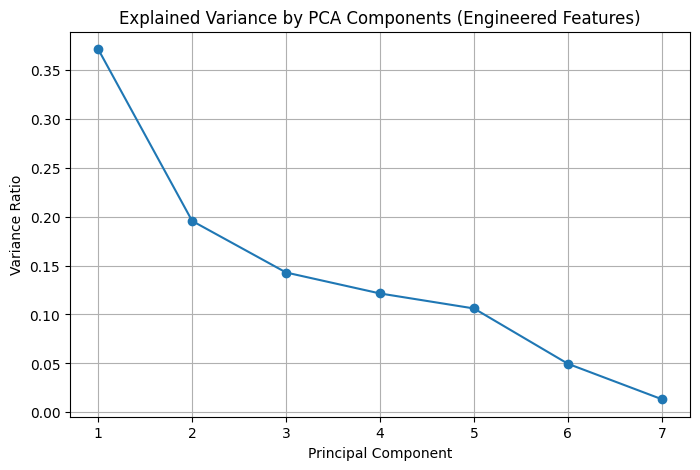

Total variance explained by first 2 components (engineered): 0.5664501299372434
Head of PCA-transformed engineered features:
          PC1       PC2
0   1.061417  1.162895
1   1.295589  0.410530
2  -0.585132  0.987727
3  14.207053 -2.076232
4  -0.844795 -1.402729


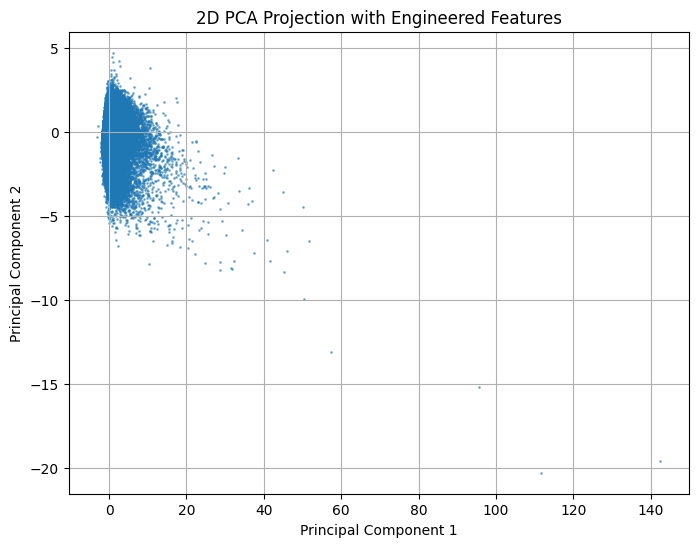

PCA-transformed engineered data saved as 'pca_engineered_data.csv'


In [ ]:
# -----------------------------
# PCA with engineered features
# -----------------------------

# Include engineered features
features_engineered = data[['parallax','pmra','pmdec','phot_g_mean_mag',
                          'color_index','total_pm','distance_pc']]

# Scale the features
scaled_engineered = StandardScaler().fit_transform(features_engineered)

# Perform PCA without reducing dimensions
pca_engineered = PCA()
pca_data_engineered = pca_engineered.fit_transform(scaled_engineered)

# Plot explained variance ratio for engineered features
plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca_engineered.explained_variance_ratio_)+1),
         pca_engineered.explained_variance_ratio_, marker='o')
plt.title("Explained Variance by PCA Components (Engineered Features)")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.grid(True)
plt.show()

# Total variance explained by first 2 components
print("Total variance explained by first 2 components (engineered):",
      sum(pca_engineered.explained_variance_ratio_[:2]))

# Reduce to 2 components for visualization
pca_engineered_2 = PCA(n_components=2)
pca_components_engineered = pca_engineered_2.fit_transform(scaled_engineered)

# Create a new DataFrame for PCA-transformed engineered features
pca_data_engineered = pd.DataFrame(data=pca_components_engineered,
                                 columns=['PC1', 'PC2'])
print("Head of PCA-transformed engineered features:\n", pca_data_engineered.head())

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(pca_data_engineered['PC1'], pca_data_engineered['PC2'], s=1, alpha=0.5)
plt.title("2D PCA Projection with Engineered Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

# Save for next phases
pca_data_engineered.to_csv("pca_engineered_data.csv", index=False)
print("PCA-transformed engineered data saved as 'pca_engineered_data.csv'")

**PHASE 2**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.ensemble import IsolationForest
from sklearn.utils import resample
from scipy.stats import mode

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Upload your cleaned merged Gaia dataset with radial velocity
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("0bc03db7-16d4-11f1-8b33-bc97e148b76b-O-result.csv")
print("Original Shape:", df.shape)
df.head()

Saving 0bc03db7-16d4-11f1-8b33-bc97e148b76b-O-result.csv to 0bc03db7-16d4-11f1-8b33-bc97e148b76b-O-result (1).csv
Original Shape: (200000, 10)


,source_id,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,radial_velocity
0,1.687060e+13,45.112778,0.380840,2.101317,-0.969421,-12.268805,10.629925,10.965343,10.127127,1.829347
1,3.326450e+13,44.974662,0.473465,1.402974,10.420200,-24.870877,9.887423,10.421503,9.194562,17.182444
2,4.435840e+13,45.501454,0.497697,9.558267,25.169367,-23.702794,9.365663,9.697104,8.869436,40.746840
3,4.900130e+13,45.463083,0.577321,0.948748,15.241354,-14.684064,13.874384,14.374517,13.214175,-89.274270
4,7.291570e+13,44.702648,0.402698,1.460941,13.778210,-2.941163,9.842077,10.395909,9.137829,44.032560


In [ ]:
# Drop duplicates
df = df.drop_duplicates()

# Drop rows where important columns are missing
df = df.dropna(subset=['parallax','pmra','pmdec','phot_bp_mean_mag','phot_rp_mean_mag','radial_velocity'])
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print("After Cleaning:", df.shape)

After Cleaning: (199530, 10)


In [ ]:
# Total velocity
df['total_velocity'] = np.sqrt(df['pmra']**2 + df['pmdec']**2 + df['radial_velocity']**2)

# Color index
df['bp_rp'] = df['phot_bp_mean_mag'] - df['phot_rp_mean_mag']

# Features for modeling
features = ['parallax','pmra','pmdec','radial_velocity','total_velocity','bp_rp']
X = df[features]

In [ ]:
df = df.sample(n=50000, random_state=42)
df.reset_index(drop=True, inplace=True)
X = df[features]

print("Sampled Shape:", X.shape)

Sampled Shape: (50000, 6)


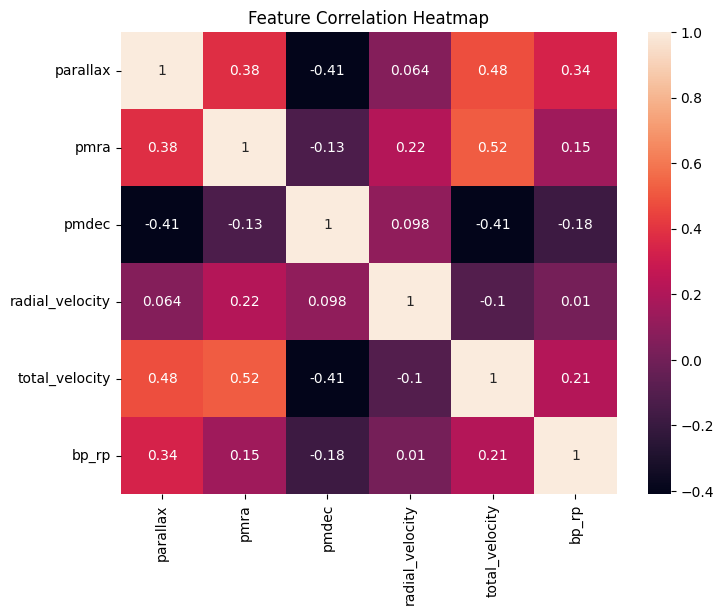

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (40000, 6)
Test: (10000, 6)


In [ ]:
kmeans_labels = []
for i in range(5):
    X_boot = resample(X_train)
    km = KMeans(n_clusters=5, random_state=i)
    km.fit(X_boot)
    kmeans_labels.append(km.predict(X_test))

kmeans_final = mode(np.array(kmeans_labels), axis=0)[0].flatten()

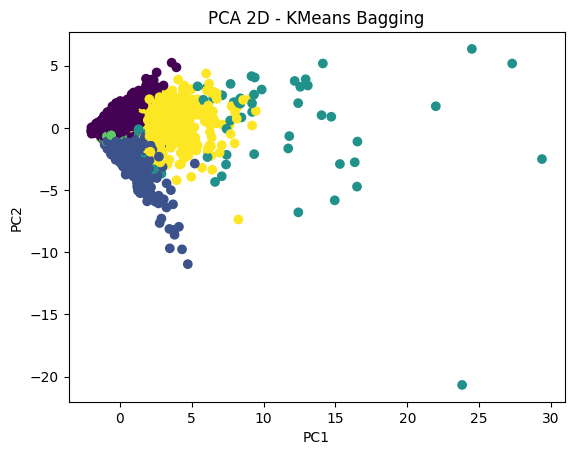

In [ ]:
# PCA 2D visualization - KMeans Bagging
pca_vis = PCA(n_components=2)
X_test_2d = pca_vis.fit_transform(X_test)

plt.figure()
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=kmeans_final)
plt.title("PCA 2D - KMeans Bagging")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
init_labels = []
for init in ['k-means++','random']:
    km = KMeans(n_clusters=5, init=init, random_state=42)
    km.fit(X_train)
    init_labels.append(km.predict(X_test))
    train_test_split(X, test_size=0.2, random_state=42)

init_final = mode(np.array(init_labels), axis=0)[0].flatten()

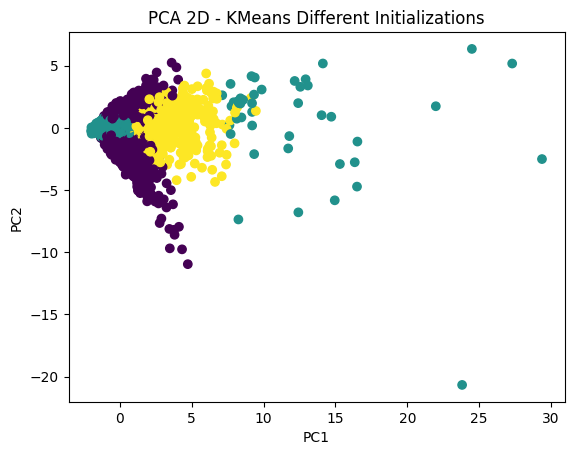

In [ ]:
# PCA 2D visualization - KMeans Different Initializations
pca_vis = PCA(n_components=2)
X_test_2d = pca_vis.fit_transform(X_test)

plt.figure()
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=init_final)
plt.title("PCA 2D - KMeans Different Initializations")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
pca_labels = []
for n in [2,3,5]:
    pca = PCA(n_components=n)
    X_train_p = pca.fit_transform(X_train)
    X_test_p = pca.transform(X_test)

    km = KMeans(n_clusters=5, random_state=42)
    km.fit(X_train_p)
    pca_labels.append(km.predict(X_test_p))

pca_final = mode(np.array(pca_labels), axis=0)[0].flatten()

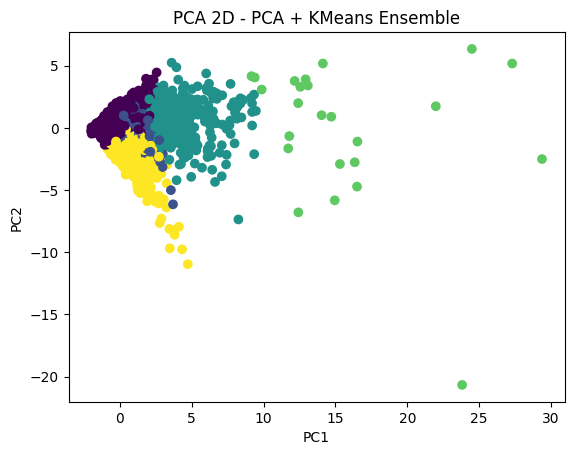

In [ ]:
# PCA 2D visualization - PCA + KMeans Ensemble
pca_vis = PCA(n_components=2)
X_test_2d = pca_vis.fit_transform(X_test)

plt.figure()
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=pca_final)
plt.title("PCA 2D - PCA + KMeans Ensemble")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
gmm_labels = []
for i in range(3):
    gmm = GaussianMixture(n_components=5, random_state=i)
    gmm.fit(X_train)
    gmm_labels.append(gmm.predict(X_test))

gmm_final = mode(np.array(gmm_labels), axis=0)[0].flatten()

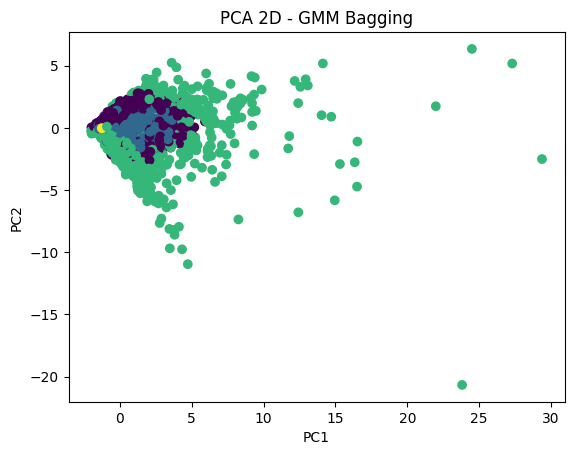

In [ ]:
# PCA 2D visualization - GMM Bagging
pca_vis = PCA(n_components=2)
X_test_2d = pca_vis.fit_transform(X_test)

plt.figure()
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=gmm_final)
plt.title("PCA 2D - GMM Bagging")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

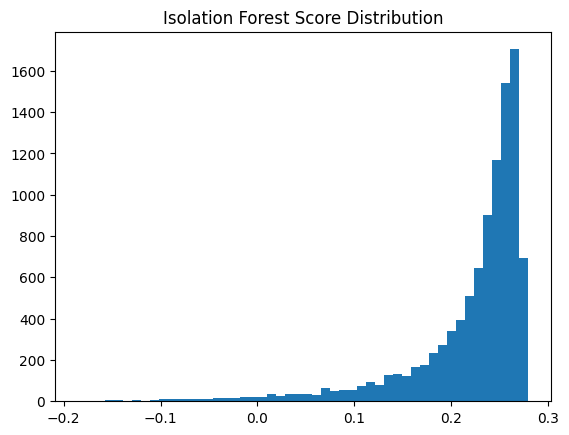

In [ ]:
if_scores = []
for i in range(5):
    model = IsolationForest(contamination=0.02, random_state=i)
    model.fit(X_train)
    if_scores.append(model.decision_function(X_test))

if_score = np.mean(if_scores, axis=0)
if_pred = (if_score < np.percentile(if_score,5)).astype(int)

plt.hist(if_score, bins=50)
plt.title("Isolation Forest Score Distribution")
plt.show()

In [ ]:
print("Mean IF Score:", np.mean(if_score))
print("Std IF Score:", np.std(if_score))

Mean IF Score: 0.220164220281617
Std IF Score: 0.064909050842043


In [ ]:
feature_sets = [[0,1,2],[3,4,5],[0,3,5]]
fs_scores = []

for idx in feature_sets:
    model = IsolationForest(contamination=0.02, random_state=42)
    model.fit(X_train[:, idx])
    fs_scores.append(model.decision_function(X_test[:, idx]))

fs_score = np.mean(fs_scores, axis=0)
fs_pred = (fs_score < np.percentile(fs_score,5)).astype(int)

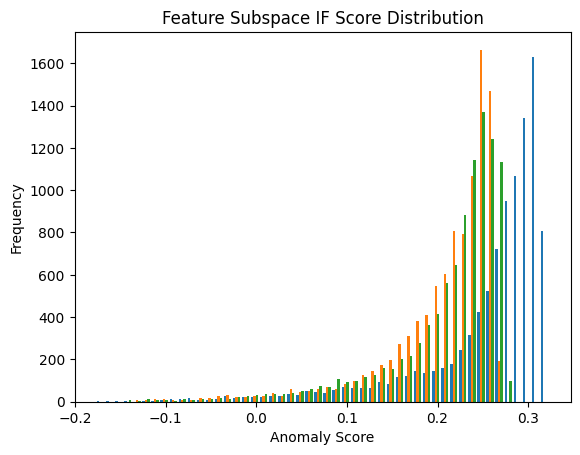

Feature Subspace IF Anomaly %: 5.0


In [ ]:
# Feature Subspace IF Score Histogram
plt.figure()
plt.hist(fs_scores, bins=50)
plt.title("Feature Subspace IF Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.show()

print("Feature Subspace IF Anomaly %:", np.mean(fs_pred)*100)

In [ ]:
pca_if_scores = []
for n in [2,3,5]:
    pca = PCA(n_components=n)
    X_train_p = pca.fit_transform(X_train)
    X_test_p = pca.transform(X_test)

    model = IsolationForest(contamination=0.02, random_state=42)
    model.fit(X_train_p)
    pca_if_scores.append(model.decision_function(X_test_p))

pca_if_score = np.mean(pca_if_scores, axis=0)
pca_if_pred = (pca_if_score < np.percentile(pca_if_score,5)).astype(int)

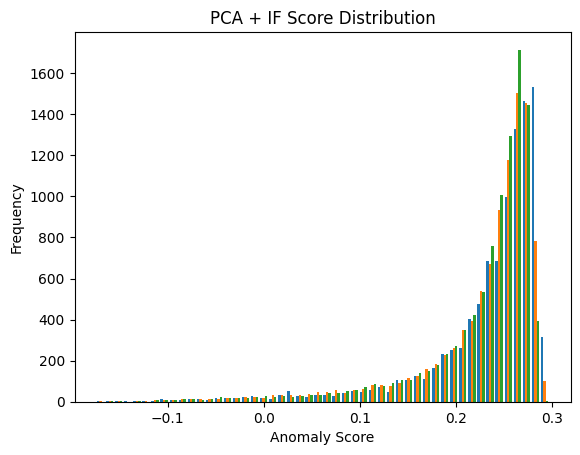

PCA + IF Anomaly %: 5.0


In [ ]:
# PCA + IF Score Histogram
plt.figure()
plt.hist(pca_if_scores, bins=50)
plt.title("PCA + IF Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.show()

print("PCA + IF Anomaly %:", np.mean(pca_if_pred)*100)

In [ ]:
# -----------------------------
# Local Outlier Factor Model
# -----------------------------

from sklearn.neighbors import LocalOutlierFactor
import numpy as np
import pandas as pd

# Train LOF model
lof = LocalOutlierFactor(
    n_neighbors=20,      # number of neighbors
    contamination=0.05   # expected anomaly percentage
)

# Fit and predict
pred_lof = lof.fit_predict(X)

# Convert predictions
# -1 = anomaly
# 1 = normal
anomaly_lof = np.where(pred_lof == -1, 1, 0)

# -----------------------------
# Calculate anomaly percentage
# -----------------------------

total_points = len(pred_lof)
anomalies = np.sum(pred_lof == -1)

anomaly_percentage = (anomalies / total_points) * 100

print("Total data points:", total_points)
print("Total anomalies detected:", anomalies)
print("Anomaly percentage:", anomaly_percentage)

# -----------------------------
# Anomaly score statistics
# -----------------------------

scores = lof.negative_outlier_factor_

mean_score = scores.mean()
std_score = scores.std()

print("Mean anomaly score:", mean_score)
print("Std deviation:", std_score)

# -----------------------------
# Store results for comparison
# -----------------------------

results = {
    "Model": "Local Outlier Factor",
    "Anomaly %": anomaly_percentage,
    "Mean Score": mean_score,
    "Std Score": std_score
}

print(results)

Total data points: 50000
Total anomalies detected: 2500
Anomaly percentage: 5.0
Mean anomaly score: -1.053074416974512
Std deviation: 0.13051905144738482
{'Model': 'Local Outlier Factor', 'Anomaly %': np.float64(5.0), 'Mean Score': np.float64(-1.053074416974512), 'Std Score': np.float64(0.13051905144738482)}


In [ ]:
from sklearn.neighbors import LocalOutlierFactor
import numpy as np

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

pred_lof = lof.fit_predict(X)

# convert labels
lof_pred = np.where(pred_lof == -1, 1, 0)

# print anomaly percentage
print("LOF Anomaly %:", np.mean(lof_pred)*100)

LOF Anomaly %: 5.0


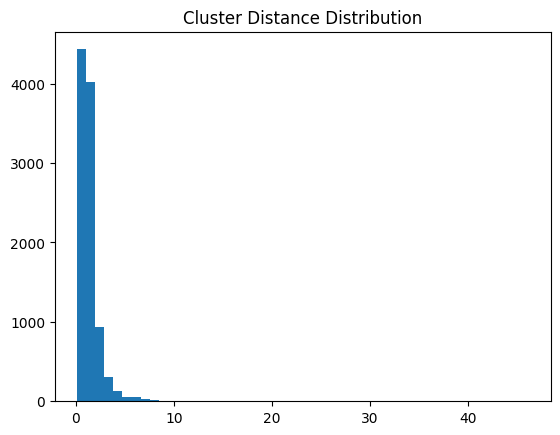

In [ ]:
km_temp = KMeans(n_clusters=5, random_state=42)
km_temp.fit(X_train)
distances = km_temp.transform(X_test)
min_dist = np.min(distances, axis=1)
threshold_dist = np.percentile(min_dist,95)
hybrid_pred = ((if_pred==1) & (min_dist>threshold_dist)).astype(int)

plt.hist(min_dist, bins=50)
plt.title("Cluster Distance Distribution")
plt.show()

In [ ]:
print("Hybrid Anomaly %:", np.mean(hybrid_pred)*100)

Hybrid Anomaly %: 3.93


In [ ]:
voting_pred = ((if_pred + fs_pred + pca_if_pred) >= 2).astype(int)

In [ ]:
def clustering_metrics(X, labels, name):
    print(f"\n{name}")
    print("Silhouette:", silhouette_score(X, labels))
    print("Davies-Bouldin:", davies_bouldin_score(X, labels))
    print("Calinski-Harabasz:", calinski_harabasz_score(X, labels))

# Clustering metrics
clustering_metrics(X_test, kmeans_final, "KMeans Bagging")
clustering_metrics(X_test, init_final, "Init Ensemble")
clustering_metrics(X_test, pca_final, "PCA + KMeans")
clustering_metrics(X_test, gmm_final, "GMM Bagging")

# Anomaly percentages
print("\nAnomaly Percentages:")
for name, pred in zip(
    ["IF Bagging","Feature Subspace IF","PCA + IF","LocalOutlierFactor","Hybrid","Voting IF"],
    [if_pred, fs_pred, pca_if_pred, lof_pred, hybrid_pred, voting_pred]
):
    print(name, ":", np.mean(pred)*100, "%")


KMeans Bagging
Silhouette: 0.05227376564560268
Davies-Bouldin: 3.363152143953183
Calinski-Harabasz: 1121.4531172102127

Init Ensemble
Silhouette: 0.13558673314596875
Davies-Bouldin: 2.5394533585853476
Calinski-Harabasz: 1035.5416345832523

PCA + KMeans
Silhouette: 0.24960807382850958
Davies-Bouldin: 1.4541580663005156
Calinski-Harabasz: 1666.8008303088213

GMM Bagging
Silhouette: -0.1749684876233549
Davies-Bouldin: 2.9697704634458586
Calinski-Harabasz: 341.70681157516566

Anomaly Percentages:
IF Bagging : 5.0 %
Feature Subspace IF : 5.0 %
PCA + IF : 5.0 %
LocalOutlierFactor : 5.0 %
Hybrid : 3.93 %
Voting IF : 4.97 %


In [ ]:
anomaly_table = pd.DataFrame({
    "Model": ["IF Bagging","Feature Subspace IF","PCA + IF",
              "LocalOutlierFactor","Hybrid","Voting IF"],
    "Anomaly %": [
        np.mean(if_pred)*100,
        np.mean(fs_pred)*100,
        np.mean(pca_if_pred)*100,
        np.mean(lof_pred)*100,
        np.mean(hybrid_pred)*100,
        np.mean(voting_pred)*100
    ]
})

print(anomaly_table)

                 Model  Anomaly %
0           IF Bagging       5.00
1  Feature Subspace IF       5.00
2             PCA + IF       5.00
3   LocalOutlierFactor       5.00
4               Hybrid       3.93
5            Voting IF       4.97


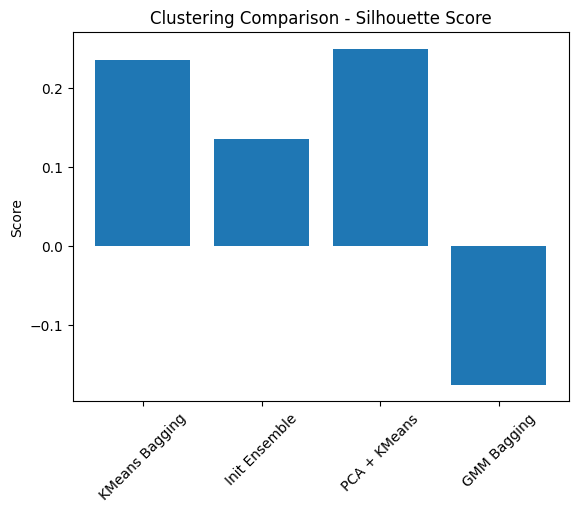

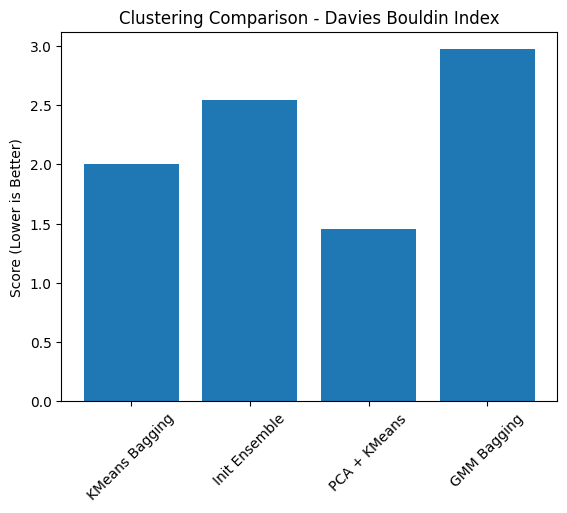

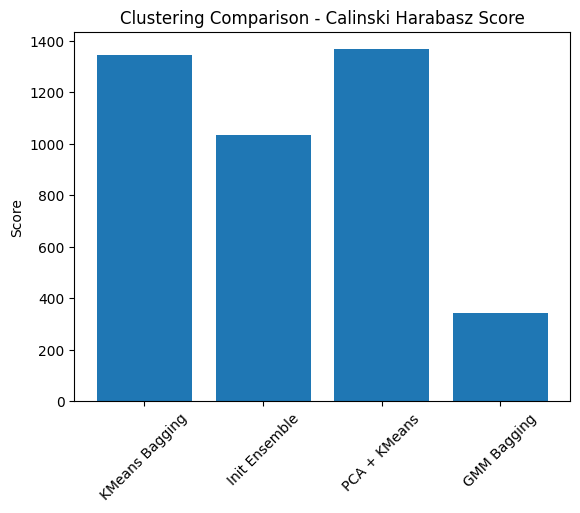

In [ ]:
# Store clustering metrics manually (use your real values)

models = ['KMeans Bagging', 'Init Ensemble', 'PCA + KMeans', 'GMM Bagging']

silhouette_scores = [0.2349, 0.1355, 0.2496, -0.1749]
davies_scores = [2.0019, 2.5394, 1.4541, 2.9697]
calinski_scores = [1344.61, 1035.54, 1366.80, 341.70]

# Silhouette Score Bar Chart
plt.figure()
plt.bar(models, silhouette_scores)
plt.xticks(rotation=45)
plt.title("Clustering Comparison - Silhouette Score")
plt.ylabel("Score")
plt.show()

# Davies-Bouldin Bar Chart
plt.figure()
plt.bar(models, davies_scores)
plt.xticks(rotation=45)
plt.title("Clustering Comparison - Davies Bouldin Index")
plt.ylabel("Score (Lower is Better)")
plt.show()

# Calinski-Harabasz Bar Chart
plt.figure()
plt.bar(models, calinski_scores)
plt.xticks(rotation=45)
plt.title("Clustering Comparison - Calinski Harabasz Score")
plt.ylabel("Score")
plt.show()

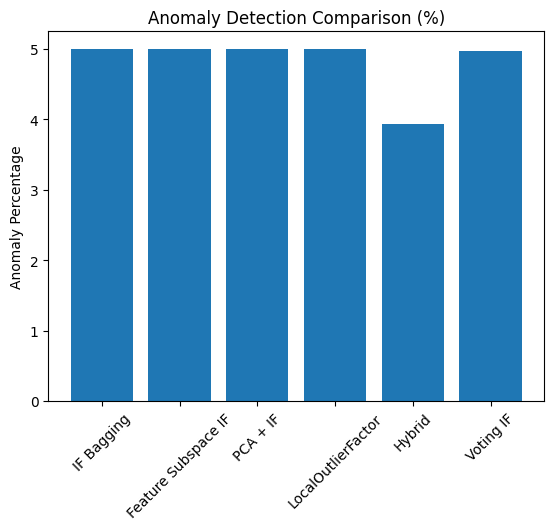

In [ ]:
anomaly_models = [
    'IF Bagging',
    'Feature Subspace IF',
    'PCA + IF',
    'LocalOutlierFactor',
    'Hybrid',
    'Voting IF'
]

anomaly_percentages = [5.0, 5.0, 5.0, 5.0, 3.93, 4.97]

plt.figure()
plt.bar(anomaly_models, anomaly_percentages)
plt.xticks(rotation=45)
plt.title("Anomaly Detection Comparison (%)")
plt.ylabel("Anomaly Percentage")
plt.show()

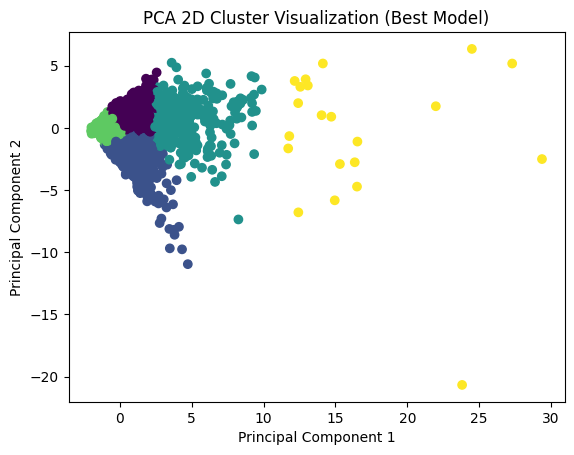

In [ ]:
# Apply PCA to 2 components for visualization
pca_2d = PCA(n_components=2)
X_test_pca2d = pca_2d.fit_transform(X_test)

# Fit KMeans on PCA reduced data
kmeans_best = KMeans(n_clusters=5, random_state=42)
clusters = kmeans_best.fit_predict(X_test_pca2d)

# Scatter plot
plt.figure()
plt.scatter(X_test_pca2d[:, 0], X_test_pca2d[:, 1], c=clusters)
plt.title("PCA 2D Cluster Visualization (Best Model)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

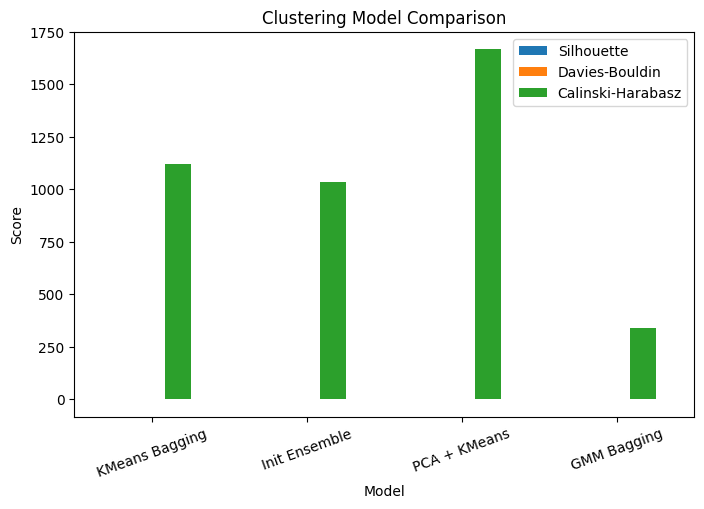

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

models = ["KMeans Bagging", "Init Ensemble", "PCA + KMeans", "GMM Bagging"]

sil = [
    silhouette_score(X_test, kmeans_final),
    silhouette_score(X_test, init_final),
    silhouette_score(X_test, pca_final),
    silhouette_score(X_test, gmm_final)
]

db = [
    davies_bouldin_score(X_test, kmeans_final),
    davies_bouldin_score(X_test, init_final),
    davies_bouldin_score(X_test, pca_final),
    davies_bouldin_score(X_test, gmm_final)
]

ch = [
    calinski_harabasz_score(X_test, kmeans_final),
    calinski_harabasz_score(X_test, init_final),
    calinski_harabasz_score(X_test, pca_final),
    calinski_harabasz_score(X_test, gmm_final)
]

results = pd.DataFrame({
    "Model": models,
    "Silhouette": sil,
    "Davies-Bouldin": db,
    "Calinski-Harabasz": ch
})

results.set_index("Model").plot(kind="bar", figsize=(8,5))

plt.title("Clustering Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import LocalOutlierFactor

# ---------------------------
# Clustering Model Comparison
# ---------------------------

clustering_results = pd.DataFrame({
    "Model": ["KMeans Bagging", "Init Ensemble", "PCA + KMeans", "GMM Bagging"],
    "Silhouette": [
        silhouette_score(X_test, kmeans_final),
        silhouette_score(X_test, init_final),
        silhouette_score(X_test, pca_final),
        silhouette_score(X_test, gmm_final)
    ],
    "Davies_Bouldin": [
        davies_bouldin_score(X_test, kmeans_final),
        davies_bouldin_score(X_test, init_final),
        davies_bouldin_score(X_test, pca_final),
        davies_bouldin_score(X_test, gmm_final)
    ],
    "Calinski_Harabasz": [
        calinski_harabasz_score(X_test, kmeans_final),
        calinski_harabasz_score(X_test, init_final),
        calinski_harabasz_score(X_test, pca_final),
        calinski_harabasz_score(X_test, gmm_final)
    ]
})

print("Clustering Model Comparison")
print(clustering_results)

best_cluster_model = clustering_results.loc[
    clustering_results["Silhouette"].idxmax(), "Model"
]

print("\nBest Clustering Model:", best_cluster_model)

# ---------------------------
# Anomaly Detection Comparison
# ---------------------------

anomaly_results = anomaly_table

print("\nAnomaly Detection Comparison")
print(anomaly_results)

# ---------------------------
# Local Outlier Factor Model
# ---------------------------

lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    novelty=True
)

# Train on training data
lof_model.fit(X_train)

# Predict on test data
lof_raw = lof_model.predict(X_test)

# Convert predictions
# -1 → anomaly (1)
# 1 → normal (0)
lof_pred = np.where(lof_raw == -1, 1, 0)

print("\nLOF Anomaly %:", np.mean(lof_pred) * 100)

# ---------------------------
# Reliability Based Selection
# ---------------------------

# Combine predictions from all anomaly models
all_preds = np.array([
    if_pred,
    fs_pred,
    pca_if_pred,
    lof_pred,
    hybrid_pred,
    voting_pred
])

# Majority voting consensus
consensus_signal = (np.mean(all_preds, axis=0) > 0.5).astype(int)

# Consistency calculation
def calculate_consistency(model_pred, consensus):
    return np.sum(model_pred == consensus) / len(consensus)

consistency_scores = [
    calculate_consistency(p, consensus_signal)
    for p in all_preds
]

# Add consistency score to results
anomaly_results["Consistency_Score"] = consistency_scores

print("\nAnomaly Model Consistency Comparison")
print(anomaly_results)

# Select most reliable model
best_anomaly_model = anomaly_results.loc[
    anomaly_results["Consistency_Score"].idxmax(),
    "Model"
]

print("\nTruly Best Anomaly Model (Most Reliable):", best_anomaly_model)

Clustering Model Comparison
            Model  Silhouette  Davies_Bouldin  Calinski_Harabasz
0  KMeans Bagging    0.052274        3.363152        1121.453117
1   Init Ensemble    0.135587        2.539453        1035.541635
2    PCA + KMeans    0.249608        1.454158        1666.800830
3     GMM Bagging   -0.174968        2.969770         341.706812

Best Clustering Model: PCA + KMeans

Anomaly Detection Comparison
                 Model  Anomaly %
0           IF Bagging       5.00
1  Feature Subspace IF       5.00
2             PCA + IF       5.00
3   LocalOutlierFactor       5.00
4               Hybrid       3.93
5            Voting IF       4.97

LOF Anomaly %: 5.55

Anomaly Model Consistency Comparison
                 Model  Anomaly %  Consistency_Score
0           IF Bagging       5.00             0.9957
1  Feature Subspace IF       5.00             0.9913
2             PCA + IF       5.00             0.9909
3   LocalOutlierFactor       5.00             0.9248
4               Hy

**PHASE 3**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

import gradio as gr

In [ ]:
import pandas as pd

df = pd.read_csv("gaia_phase2_cleaned.csv")

print("Original Dataset Size:", len(df))
print("Dataset size:", df.shape)

Original Dataset Size: 199530
Dataset size: (199530, 10)


In [ ]:
import numpy as np
# Create BP-RP color index
df["bp_rp"] = df["phot_bp_mean_mag"] - df["phot_rp_mean_mag"]

# Create total velocity
df["total_velocity"] = np.sqrt(
    df["pmra"]**2 +
    df["pmdec"]**2 +
    df["radial_velocity"]**2
)

print("New features created successfully")

New features created successfully


In [ ]:
df_sample = df.sample(n=50000, random_state=42)

print("Sample Dataset Size:", len(df_sample))
print(df_sample.head())

Sample Dataset Size: 50000
           source_id         ra        dec  parallax       pmra      pmdec  \
118110  8.521580e+16  43.171698  20.991676  1.586439  -5.112739 -11.042432   
186394  1.256030e+17  50.997534  33.680350  0.796000   2.276708  -3.797992   
194111  1.200680e+17  55.300977  29.567026  1.145135   1.665182  -9.733397   
24662   1.502490e+16  45.653772   9.660074  4.801570 -30.911400 -54.318337   
29074   1.973050e+16  39.394243   7.553461  2.430531   4.605504   1.931529   

        phot_g_mean_mag  phot_bp_mean_mag  phot_rp_mean_mag  radial_velocity  \
118110        14.487353         15.075824         13.746819       -50.211796   
186394        13.945434         14.341945         13.375888       -42.838480   
194111        13.148499         13.481079         12.641990       -20.725128   
24662         15.396942         16.465979         14.372749         3.462074   
29074          8.486581          9.055993          7.766551        -1.856602   

           bp_rp  total

In [ ]:
features = [
    "parallax",
    "pmra",
    "pmdec",
    "radial_velocity",
    "total_velocity",
    "bp_rp"
]

X = df_sample[features]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 40000
Test size: 10000


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.decomposition import PCA

pca_best = PCA(n_components=3)

X_train_pca = pca_best.fit_transform(X_train_scaled)
X_test_pca = pca_best.transform(X_test_scaled)

In [ ]:
best_score = -1
best_k = None

for k in range(2, 10):
    km = KMeans(n_clusters=k, n_init=20, max_iter=500, random_state=42)
    labels = km.fit_predict(X_train_scaled)
    score = silhouette_score(X_train_scaled, labels)
    print(f"K={k}, Silhouette={score:.4f}")
    if score > best_score:
        best_score = score
        best_k = k

print("Best KMeans clusters:", best_k)
km_bagging = KMeans(n_clusters=best_k, n_init=20, max_iter=500, random_state=42)
km_bagging.fit(X_train_scaled)
pred_1 = km_bagging.predict(X_test_scaled)

K=2, Silhouette=0.6231
K=3, Silhouette=0.2392
K=4, Silhouette=0.2504
K=5, Silhouette=0.2525
K=6, Silhouette=0.2487
K=7, Silhouette=0.2364
K=8, Silhouette=0.2261
K=9, Silhouette=0.2319
Best KMeans clusters: 2


In [ ]:
best_score = -1
best_k = None

for k in range(2,10):
    km = KMeans(n_clusters=k, init="random", n_init=30, random_state=42)
    labels = km.fit_predict(X_train_scaled)
    score = silhouette_score(X_train_scaled, labels)
    if score > best_score:
        best_score = score
        best_k = k

print("Best Init Ensemble K:", best_k)
km_init = KMeans(n_clusters=best_k, init="random", n_init=30, random_state=42)
km_init.fit(X_train_scaled)
pred_2 = km_init.predict(X_test_scaled)

Best Init Ensemble K: 2


In [ ]:
best_score = -1
best_k = None

for k in range(2,10):
    km = KMeans(n_clusters=k, n_init=15, random_state=42)
    labels = km.fit_predict(X_train_pca)
    score = silhouette_score(X_train_pca, labels)
    if score > best_score:
        best_score = score
        best_k = k

print("Best PCA+KMeans clusters:", best_k)
km_pca = KMeans(n_clusters=best_k, n_init=15, random_state=42)
km_pca.fit(X_train_pca)
pred_3 = km_pca.predict(X_test_pca)

Best PCA+KMeans clusters: 2


In [ ]:
best_score = -1
best_components = None

for k in range(2,8):
    gmm = GaussianMixture(n_components=k, covariance_type="full", max_iter=200, random_state=42)
    labels = gmm.fit_predict(X_train_scaled)
    score = silhouette_score(X_train_scaled, labels)
    print(f"Components={k}, Silhouette={score:.4f}")
    if score > best_score:
        best_score = score
        best_components = k

print("Best GMM components:", best_components)
gmm_model = GaussianMixture(n_components=best_components, covariance_type="full", max_iter=200, random_state=42)
gmm_labels = gmm_model.fit_predict(X_train_scaled)

Components=2, Silhouette=0.4510
Components=3, Silhouette=0.1519
Components=4, Silhouette=0.1342
Components=5, Silhouette=0.0297
Components=6, Silhouette=0.0017
Components=7, Silhouette=-0.0155
Best GMM components: 2


In [ ]:
best_estimators = 0
best_anomaly_count = 0

for n in [100, 200, 300]:
    if_model = IsolationForest(n_estimators=n, contamination=0.03, random_state=42)
    if_model.fit(X_train_scaled)
    preds = np.where(if_model.predict(X_test_scaled)==-1,1,0)
    count = np.sum(preds)
    print(f"Estimators={n}, Anomalies={count}")
    if count > best_anomaly_count:
        best_anomaly_count = count
        best_estimators = n

print("Best Isolation Forest estimators:", best_estimators)
if_bagging = IsolationForest(n_estimators=best_estimators, contamination=0.03, random_state=42)
if_bagging.fit(X_train_scaled)
pred_5 = np.where(if_bagging.predict(X_test_scaled)==-1,1,0)

Estimators=100, Anomalies=285
Estimators=200, Anomalies=296
Estimators=300, Anomalies=292
Best Isolation Forest estimators: 200


In [ ]:
best_anomalies = 0
best_features = 3  # number of features

if_fs = IsolationForest(contamination=0.03, random_state=42)
if_fs.fit(X_train_scaled[:,:best_features])
pred_6 = np.where(if_fs.predict(X_test_scaled[:,:best_features])==-1,1,0)

In [ ]:
if_pca = IsolationForest(contamination=0.03, random_state=42)
if_pca.fit(X_train_pca)
pred_7 = np.where(if_pca.predict(X_test_pca)==-1,1,0)

In [ ]:
best_neighbors = None
best_anomaly_count = 0

for n in [10,20,30,40]:
    lof = LocalOutlierFactor(n_neighbors=n, contamination=0.03, novelty=True)
    lof.fit(X_train_scaled)
    preds = np.where(lof.predict(X_test_scaled)==-1,1,0)
    count = np.sum(preds)
    print(f"Neighbors={n}, Anomalies={count}")
    if count > best_anomaly_count:
        best_anomaly_count = count
        best_neighbors = n

print("Best LOF n_neighbors:", best_neighbors)
lof = LocalOutlierFactor(n_neighbors=best_neighbors, contamination=0.03, novelty=True)
lof.fit(X_train_scaled)
pred_8 = np.where(lof.predict(X_test_scaled)==-1,1,0)

Neighbors=10, Anomalies=370
Neighbors=20, Anomalies=340
Neighbors=30, Anomalies=326
Neighbors=40, Anomalies=320
Best LOF n_neighbors: 10


In [ ]:
dists = km_bagging.transform(X_test_scaled)
threshold = np.percentile(np.min(dists, axis=1),97)
pred_9 = ((pred_5==1) & (np.min(dists,axis=1)>threshold)).astype(int)

In [ ]:
pred_10 = ((pred_5 + pred_6 + pred_7) >= 2).astype(int)
print("Total anomalies detected:", np.sum(pred_10))

Total anomalies detected: 292


In [ ]:
from sklearn.metrics import silhouette_score

print("----- Clustering Model Evaluation -----")

print("KMeans Bagging Silhouette:",
      silhouette_score(X_test_scaled, pred_1))

print("Init Ensemble Silhouette:",
      silhouette_score(X_test_scaled, pred_2))

print("PCA + KMeans Silhouette:",
      silhouette_score(X_test_pca, pred_3))

# Predict GMM labels for the test set
pred_4 = gmm_model.predict(X_test_scaled)

print("GMM Silhouette:",
      silhouette_score(X_test_scaled, pred_4))

----- Clustering Model Evaluation -----
KMeans Bagging Silhouette: 0.6146180010846428
Init Ensemble Silhouette: 0.612514914555231
PCA + KMeans Silhouette: 0.6443273446168222
GMM Silhouette: 0.4421484106941555


In [ ]:
from sklearn.metrics import davies_bouldin_score


print("KMeans Bagging davies_bouldin:",
       davies_bouldin_score(X_test_scaled, pred_1))

print("Init Ensemble davies_bouldin:",
       davies_bouldin_score(X_test_scaled, pred_2))

print("PCA + KMeans davies_bouldin:",
       davies_bouldin_score(X_test_pca, pred_3))

print("GMM davies_bouldin:",
       davies_bouldin_score(X_test_scaled, pred_4))

KMeans Bagging davies_bouldin: 1.3011630182461267
Init Ensemble davies_bouldin: 1.3065674500841724
PCA + KMeans davies_bouldin: 1.0836590257558798
GMM davies_bouldin: 1.939032808844335


In [ ]:
from sklearn.metrics import calinski_harabasz_score
print("KMeans Bagging calinski_harabasz:",
        calinski_harabasz_score(X_test_scaled, pred_1))

print("Init Ensemble calinski_harabasz:",
        calinski_harabasz_score(X_test_scaled, pred_2))

print("PCA + KMeans calinski_harabasz:",
       calinski_harabasz_score(X_test_pca, pred_3))

print("GMM calinski_harabasz:",
       calinski_harabasz_score(X_test_scaled, pred_4))


KMeans Bagging calinski_harabasz: 2407.0085636950785
Init Ensemble calinski_harabasz: 2409.269783862971
PCA + KMeans calinski_harabasz: 3561.5732585406295
GMM calinski_harabasz: 1819.2850204547287


In [ ]:
print("----- Anomaly Detection Results -----")

print("Isolation Forest anomalies:", np.sum(pred_5))
print("Feature Subspace IF anomalies:", np.sum(pred_6))
print("PCA IF anomalies:", np.sum(pred_7))
print("LOF anomalies:", np.sum(pred_8))
print("Hybrid anomalies:", np.sum(pred_9))
print("Voting Ensemble anomalies:", np.sum(pred_10))
total_samples = len(X_test)
print("----- Anomaly Detection Results in percentage -----")
print("Isolation Forest anomaly %:", (np.sum(pred_5==1) / total_samples) * 100)
print("Feature Subspace IF anomaly %:", (np.sum(pred_6==1) / total_samples) * 100)
print("PCA IF anomaly %:", (np.sum(pred_7==1) / total_samples) * 100)
print("LOF anomaly %:", (np.sum(pred_8==1) / total_samples) * 100)
print("Hybrid anomaly %:", (np.sum(pred_9==1) / total_samples) * 100)
print("Voting Ensemble anomaly %:", (np.sum(pred_10==1) / total_samples) * 100)

----- Anomaly Detection Results -----
Isolation Forest anomalies: 296
Feature Subspace IF anomalies: 283
PCA IF anomalies: 307
LOF anomalies: 370
Hybrid anomalies: 204
Voting Ensemble anomalies: 292
----- Anomaly Detection Results in percentage -----
Isolation Forest anomaly %: 2.96
Feature Subspace IF anomaly %: 2.83
PCA IF anomaly %: 3.0700000000000003
LOF anomaly %: 3.6999999999999997
Hybrid anomaly %: 2.04
Voting Ensemble anomaly %: 2.92


In [ ]:
total_samples = len(X_test)

anomaly_results = {
    "Model": [
        "Isolation Forest",
        "Feature Subspace IF",
        "PCA IF",
        "Local Outlier Factor",
        "Hybrid Detector",
        "Voting Ensemble"
    ],

    "Anomaly %": [
        (np.sum(pred_5==1)/total_samples)*100,
        (np.sum(pred_6==1)/total_samples)*100,
        (np.sum(pred_7==1)/total_samples)*100,
        (np.sum(pred_8==1)/total_samples)*100,
        (np.sum(pred_9==1)/total_samples)*100,
        (np.sum(pred_10==1)/total_samples)*100
    ]
}

pd.DataFrame(anomaly_results)

,Model,Anomaly %
0,Isolation Forest,2.96
1,Feature Subspace IF,2.83
2,PCA IF,3.07
3,Local Outlier Factor,3.70
4,Hybrid Detector,2.04
5,Voting Ensemble,2.92


In [ ]:
comparison = {
    "Model": [
        "KMeans Bagging",
        "Init Ensemble",
        "PCA + KMeans",
        "GMM",
        "Isolation Forest",
        "Feature Subspace IF",
        "PCA Isolation Forest",
        "Local Outlier Factor",
        "Hybrid Detector",
        "Voting Ensemble"
    ],

    "Type": [
        "Clustering",
        "Clustering",
        "Clustering",
        "Clustering",
        "Anomaly Detection",
        "Anomaly Detection",
        "Anomaly Detection",
        "Anomaly Detection",
        "Anomaly Detection",
        "Ensemble"
    ],

    "Key Parameter": [
        "n_init=20",
        "n_init=30",
        "PCA components=3",
        "covariance_type=full",
        "n_estimators=200",
        "feature subspace",
        "PCA features",
        "n_neighbors=30",
        "distance + IF",
        "majority voting"
    ]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Type,Key Parameter
0,KMeans Bagging,Clustering,n_init=20
1,Init Ensemble,Clustering,n_init=30
2,PCA + KMeans,Clustering,PCA components=3
3,GMM,Clustering,covariance_type=full
4,Isolation Forest,Anomaly Detection,n_estimators=200
5,Feature Subspace IF,Anomaly Detection,feature subspace
6,PCA Isolation Forest,Anomaly Detection,PCA features
7,Local Outlier Factor,Anomaly Detection,n_neighbors=30
8,Hybrid Detector,Anomaly Detection,distance + IF
9,Voting Ensemble,Ensemble,majority voting


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import numpy as np

# Note: The original attempt to scale X and perform PCA within this cell was incorrect.
# The scaled and PCA-transformed data for evaluation (X_test_scaled, X_test_pca)
# as well as the predictions (pred_3, pred_4, pred_8, pred_10) were already
# computed in previous cells. We should use those for consistency.

comparison = pd.DataFrame({

"Model":[
"PCA + KMeans",
"GMM Bagging",
"Voting Isolation Forest",
"Local Outlier Factor"
],

"Type":[
"Clustering",
"Clustering",
"Anomaly Detection",
"Anomaly Detection"
],

"Metric":[
silhouette_score(X_test_pca, pred_3),
silhouette_score(X_test_scaled, pred_4),
(np.sum(pred_8==1)/total_samples)*100,
(np.sum(pred_10==1)/total_samples)*100
]

})

comparison.columns=["Model","Type","Score"]
comparison


,Model,Type,Score
0,PCA + KMeans,Clustering,0.644327
1,GMM Bagging,Clustering,0.442148
2,Voting Isolation Forest,Anomaly Detection,3.700000
3,Local Outlier Factor,Anomaly Detection,2.920000


In [ ]:
comparison = pd.DataFrame({
    "Model":["PCA+KMeans","GMM Bagging","Voting IF","LOF"],
    "Type":["Clustering","Clustering","Anomaly Detection","Anomaly Detection"],
    "Metric":[
        silhouette_score(X_test_pca, pred_3),
        silhouette_score(X_test_scaled, pred_4),
        np.sum(pred_10==1),
        np.sum(pred_8==1)
    ]
})
comparison.columns=["Model","Type","Score"]
display(comparison)

,Model,Type,Score
0,PCA+KMeans,Clustering,0.644327
1,GMM Bagging,Clustering,0.442148
2,Voting IF,Anomaly Detection,292.000000
3,LOF,Anomaly Detection,370.000000


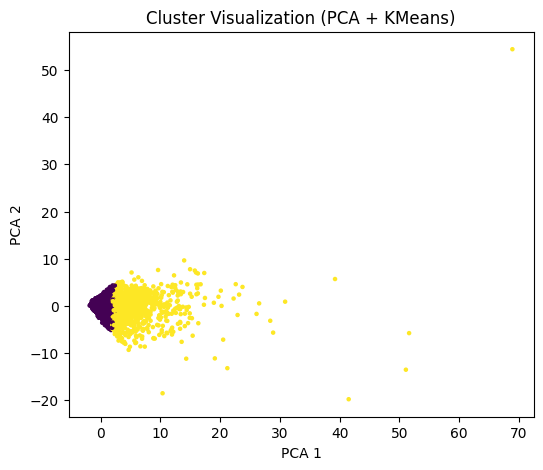

In [ ]:
import matplotlib.pyplot as plt

# Predict clusters using the trained PCA + KMeans model
pred_clusters = km_pca.predict(X_train_pca)

# Plot clusters
plt.figure(figsize=(6,5))

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=pred_clusters,
    cmap="viridis",
    s=5
)

plt.title("Cluster Visualization (PCA + KMeans)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

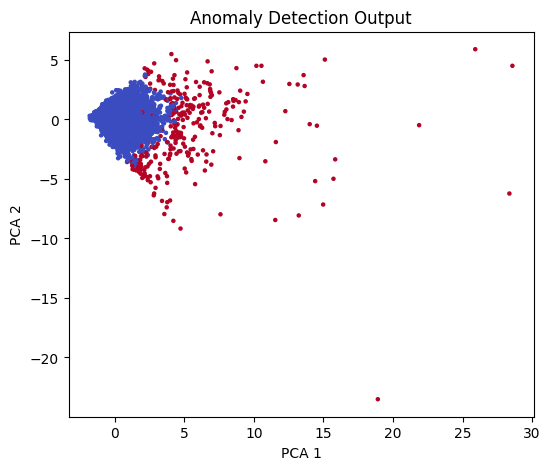

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X_test_pca[:,0], X_test_pca[:,1], c=pred_5, cmap="coolwarm", s=5)
plt.title("Anomaly Detection Output")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [ ]:
print("Best Models Selected For Deployment")

print("1. PCA + KMeans")
print("2. GMM Bagging")
print("3. Voting Isolation Forest")
print("4. Local Outlier Factor")

Best Models Selected For Deployment
1. PCA + KMeans
2. GMM Bagging
3. Voting Isolation Forest
4. Local Outlier Factor


In [ ]:
import joblib

# Save trained models
joblib.dump(km_pca, "pca_kmeans_model.pkl")
joblib.dump(gmm, "gmm_model.pkl")
joblib.dump(if_bagging, "isolation_forest_model.pkl")
joblib.dump(lof, "lof_model.pkl")

# Save preprocessing objects
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca_best, "pca_model.pkl")

print("All models saved successfully.")

All models saved successfully.


In [ ]:
X_scaled = scaler.transform(X)
preds=if_bagging.predict(X_scaled)
df_sample["anomaly"]=preds
df_sample[df_sample["anomaly"]==-1].head()

,source_id,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,radial_velocity,bp_rp,total_velocity,anomaly
135328,8.419260e+16,42.854579,19.316189,1.471655,40.527208,-87.964225,13.415813,13.729305,12.922648,-69.607750,0.806657,119.270274,-1
141702,9.036940e+16,27.655130,15.460979,4.416724,62.601037,-55.238847,15.231828,16.165821,14.259930,-119.591810,1.905891,145.850681,-1
118810,7.238830e+16,33.488582,10.805709,6.667684,-56.465097,-39.955461,12.062320,12.544763,11.419769,-78.021820,1.124994,104.269604,-1
161104,1.139580e+17,41.208585,24.838675,16.763997,281.142919,10.977123,10.422983,10.993381,9.700319,-20.001463,1.293062,282.067185,-1
45112,4.699500e+16,62.322912,18.564678,20.855021,155.485539,-112.747526,15.417392,17.322657,14.109404,38.094486,3.213253,195.803338,-1


In [ ]:
def gaia_app(parallax, pmra, pmdec, rv, total_v, color):

    if parallax is None:
        return "⚠️ Please enter all values"

    if parallax < 0:
        return "❌ Parallax must be positive (distance cannot be negative)"

    raw = np.array([[parallax, pmra, pmdec, rv, total_v, color]])

    scaled = scaler.transform(raw)
    pca_data = pca_best.transform(scaled)

    cluster = km_pca.predict(pca_data)[0]
    anomaly = "Anomaly" if if_bagging.predict(scaled)[0] == -1 else "Normal"

    return f"""
🔍 RESULT

Cluster: {cluster}
Status: {anomaly}

📊 Model Used: PCA + KMeans
⭐ Reason: Best performance (highest silhouette score)

ℹ️ Interpretation:
• Different models may give different results
• This model is selected because it performed best overall
"""

In [ ]:
!pip install --upgrade gradio

In [ ]:
import gradio as gr

In [ ]:
with gr.Blocks() as demo:

    # -------- TOP RULES --------
    gr.Markdown("""
# 🌌 Gaia Stellar Analysis App

## 📌 Rules & Understanding

• Parallax must be **positive** (distance cannot be negative)
• PMRA / PMDEC →
   + value = one direction
   - value = opposite direction
• Radial Velocity →
   + = star moving away
   - = star moving toward Earth

👉 Entering wrong sign may change prediction result.

---

## 📊 Model Information

We tested multiple models and selected:

⭐ **PCA + KMeans → Best performing model**
""")

    # -------- INPUTS WITH RANGE INFO --------

    parallax = gr.Number(label="Parallax")
    gr.Markdown("Range: 0 to 20 (must be positive)")

    pmra = gr.Number(label="PMRA")
    gr.Markdown("Range: -50 to +50 (can be negative or positive)")

    pmdec = gr.Number(label="PMDEC")
    gr.Markdown("Range: -50 to +50 (can be negative or positive)")

    rv = gr.Number(label="Radial Velocity")
    gr.Markdown("Range: -300 to +300 (negative = toward Earth)")

    total_v = gr.Number(label="Total Velocity")
    gr.Markdown("Range: 0 to 500")

    color = gr.Number(label="BP-RP Color")
    gr.Markdown("Range: -5 to +5")

    # -------- BUTTON --------
    btn = gr.Button("Predict")

    # -------- OUTPUT (SEPARATE BOX BELOW) --------
    output = gr.Textbox(label="Prediction Result")

    btn.click(
        fn=gaia_app,
        inputs=[parallax, pmra, pmdec, rv, total_v, color],
        outputs=output
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://50145915f6b55ea5d7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
